# Phase 2: Node-Level Confusion Weights

This notebook computes node-level confusion weights for phonemes and graphemes. It models intra-language confusion only, using a hybrid approach of small precomputed inventories, manual seed confusions, and automatic similarity heuristics.


In [2]:
# !pip install panphon


In [3]:
import networkx as nx
import pandas as pd
import os
import matplotlib.pyplot as plt
import json
import itertools
import difflib
import panphon.distance

# Initialize PanPhon Distance globally
dst = panphon.distance.Distance()

# Configuration
GRAPH_PATH = 'artifacts/graph.graphml'
OUTPUT_PHONEME_CSV = 'artifacts/phoneme_confusion_weights.csv'
OUTPUT_GRAPHEME_CSV = 'artifacts/grapheme_confusion_weights.csv'
OUTPUT_GRAPH_PATH = 'artifacts/graph_phase2_scriptweights.graphml'

LANGUAGES = ['np', 'ur', 'vn', 'dr']
CONFUSION_THRESHOLD = 0.45
TOP_K_NEIGHBORS = 5

# Hybrid weights
W_MANUAL = 0.45
W_HEURISTIC = 0.55


In [4]:
'''
It takes two strings (a and b).

It computes a normalized similarity ratio (between 0.0 and 1.0) based on the longest common subsequences. Its best to use 
difflib.SequenceMatcher (Gestalt pattern matching) for phonetics (IPA)

We use this to compare spelling visual layout similarity for graphemes and phonetic transcription similarities for IPA symbols without having to install external libraries like Levenshtein or textdistance.
'''

def string_similarity(a, b):
    if not a or not b: return 0.0
    matcher = difflib.SequenceMatcher(None, a, b)
    return matcher.ratio()

In [5]:
print("Loading GraphML...")
G = nx.read_graphml(GRAPH_PATH)
print(f"Loaded {len(G.nodes)} nodes and {len(G.edges)} edges.")


Loading GraphML...
Loaded 290518 nodes and 307013 edges.


In [6]:
def build_inventory(G, ntype, lang):
    """
    Extracts a bounded inventory of nodes of a specific type and language.
    Deduplicates and skips malformed nodes.
    """
    inventory = []
    seen = set()
    
    for n, data in G.nodes(data=True):
        if data.get('type') == ntype and data.get('language') == lang:
            if ntype == 'Phoneme' and not data.get('ipa'):
                continue
            if ntype == 'Grapheme' and not data.get('char'):
                continue
                
            if n not in seen:
                seen.add(n)
                inventory.append((n, data))
                
    # Stable ordering by node id
    inventory.sort(key=lambda x: x[0])
    return inventory

# Build inventories for inspection
phoneme_inventories = {lang: build_inventory(G, 'Phoneme', lang) for lang in LANGUAGES}
grapheme_inventories = {lang: build_inventory(G, 'Grapheme', lang) for lang in LANGUAGES}

for lang in LANGUAGES:
    print(f"Language: {lang} | Phonemes: {len(phoneme_inventories[lang])}, Graphemes: {len(grapheme_inventories[lang])}")


Language: np | Phonemes: 49, Graphemes: 53
Language: ur | Phonemes: 31, Graphemes: 39
Language: vn | Phonemes: 82, Graphemes: 178
Language: dr | Phonemes: 32, Graphemes: 67


In [7]:
# Load manual seeds from CSVs to act as priors in the hybrid scoring model
import os

SEED_DIR = 'data/seeds'

PHONEME_CONFUSION_SEEDS = {lang: {} for lang in LANGUAGES}
GRAPHEME_CONFUSION_SEEDS = {lang: {} for lang in LANGUAGES}

for lang in LANGUAGES:
    p_file = os.path.join(SEED_DIR, f'manual_phoneme_confusions_{lang}.csv')
    if os.path.exists(p_file):
        df_p = pd.read_csv(p_file)
        for _, row in df_p.iterrows():
            PHONEME_CONFUSION_SEEDS[lang][(row['source'], row['target'])] = float(row['seed_weight'])
            
    g_file = os.path.join(SEED_DIR, f'manual_grapheme_confusions_{lang}.csv')
    if os.path.exists(g_file):
        df_g = pd.read_csv(g_file)
        for _, row in df_g.iterrows():
            GRAPHEME_CONFUSION_SEEDS[lang][(row['source'], row['target'])] = float(row['seed_weight'])

def get_manual_prior(seeds, lang, node_a, node_b):
    if lang not in seeds: return 0.0
    lang_seeds = seeds[lang]
    # Check both directions for symmetry
    if (node_a, node_b) in lang_seeds:
        return lang_seeds[(node_a, node_b)]
    if (node_b, node_a) in lang_seeds:
        return lang_seeds[(node_b, node_a)]
    return 0.0


In [8]:
def score_phoneme_heuristic(d_a, d_b):
    ipa_a = d_a.get('ipa', '').replace('/', '')
    ipa_b = d_b.get('ipa', '').replace('/', '')
    
    # Exact identity
    if ipa_a == ipa_b: return 0.0, {}
    
    # PanPhon feature edit distance
    distance = dst.feature_edit_distance(ipa_a, ipa_b)
    
    # Convert distance to similarity (0.0 to 1.0)
    MAX_DIST = 10.0
    similarity = max(0.0, 1.0 - (distance / MAX_DIST))
    
    heuristic_score = similarity
    components = {'panphon_dist': round(distance, 3), 'ipa_sim': round(similarity, 3)}
    
    return heuristic_score, components

def score_grapheme_heuristic(d_a, d_b):
    char_a = d_a.get('char', '')
    char_b = d_b.get('char', '')
    
    if char_a == char_b: return 0.0, {}
    
    str_sim = string_similarity(char_a, char_b)
    len_diff = abs(len(char_a) - len(char_b))
    
    heuristic_score = str_sim
    components = {'char_sim': round(str_sim, 3), 'len_diff': len_diff}
    
    return heuristic_score, components


In [9]:
def build_confusion_table(ntype, inventories, seeds):
    records = []
    comparisons = 0
    
    for lang in LANGUAGES:
        nodes = inventories[lang]
        
        for (n_a, d_a), (n_b, d_b) in itertools.combinations(nodes, 2):
            val_a = d_a.get('ipa', '').replace('/', '') if ntype == 'Phoneme' else d_a.get('char', '')
            val_b = d_b.get('ipa', '').replace('/', '') if ntype == 'Phoneme' else d_b.get('char', '')
            
            manual_prior = get_manual_prior(seeds, lang, n_a, n_b)
            
            # Candidate generation rules to avoid useless comparisons
            # Rule 1: Manual seed exists
            # Rule 2: Length difference <= 1
            # Rule 3: For phonemes, same first character
            length_ok = abs(len(val_a) - len(val_b)) <= 1
            first_char_ok = (ntype == 'Phoneme' and val_a and val_b and val_a[0] == val_b[0])
            
            if manual_prior > 0 or length_ok or first_char_ok:
                comparisons += 1
                
                # Heuristic Score
                if ntype == 'Phoneme':
                    h_score, comps = score_phoneme_heuristic(d_a, d_b)
                else:
                    h_score, comps = score_grapheme_heuristic(d_a, d_b)
                
                # Hybrid Formula
                # Since single-character graphemes will always have an h_score of 0.0,--
                # a weighted average suppresses manual seeds below the threshold.
                # Max() guarantees that manual seeds act as strong priors while heuristics fill the gaps.
                final_score = max(manual_prior, h_score)
                final_score = max(0.0, min(1.0, final_score)) # Clamp
                
                source_type = 'hybrid' if manual_prior > 0 and h_score > 0 else ('manual' if manual_prior > 0 else 'heuristic')
                
                comps['manual_prior'] = manual_prior
                comps['heuristic_score'] = round(h_score, 3)
                
                if final_score >= CONFUSION_THRESHOLD:
                    rel = 'phonemeconfusablewith' if ntype == 'Phoneme' else 'graphemeconfusablewith'
                    
                    # Add symmetric edges A->B and B->A
                    for source, target in [(n_a, n_b), (n_b, n_a)]:
                        records.append({
                            'source': source,
                            'target': target,
                            'language': lang,
                            'relation': rel,
                            'weight': round(final_score, 3),
                            'source_type': source_type,
                            'symmetric': True,
                            'components': json.dumps(comps)
                        })

    df = pd.DataFrame(records)
    
    # Top-K Thresholding
    if not df.empty:
        df = df.sort_values(by=['source', 'weight'], ascending=[True, False])
        df = df.groupby('source').head(TOP_K_NEIGHBORS).reset_index(drop=True)
        
    print(f"[{ntype}] Evaluated {comparisons} candidates. Generated {len(df)} accepted edges.")
    return df

print("Building Phoneme Confusion Table...")
df_phoneme = build_confusion_table('Phoneme', phoneme_inventories, PHONEME_CONFUSION_SEEDS)

print("\nBuilding Grapheme Confusion Table...")
df_grapheme = build_confusion_table('Grapheme', grapheme_inventories, GRAPHEME_CONFUSION_SEEDS)


Building Phoneme Confusion Table...
[Phoneme] Evaluated 3604 candidates. Generated 949 accepted edges.

Building Grapheme Confusion Table...
[Grapheme] Evaluated 18884 candidates. Generated 243 accepted edges.


In [10]:
def insert_confusion_edges(G, df):
    count = 0
    for _, row in df.iterrows():
        src = row['source']
        tgt = row['target']
        G.add_edge(src, tgt, 
                   relation=row['relation'],
                   weight=row['weight'],
                   language=row['language'],
                   source_type=row['source_type'],
                   symmetric=row['symmetric'],
                   components=row['components'])
        count += 1
    return count

print("Inserting accepted edges into Graph...")
p_count = insert_confusion_edges(G, df_phoneme)
g_count = insert_confusion_edges(G, df_grapheme)
print(f"Successfully inserted {p_count} phoneme edges and {g_count} grapheme edges.")

# Export tables
df_phoneme.to_csv(OUTPUT_PHONEME_CSV, index=False)
df_grapheme.to_csv(OUTPUT_GRAPHEME_CSV, index=False)


Inserting accepted edges into Graph...
Successfully inserted 949 phoneme edges and 243 grapheme edges.


In [11]:
def validate_no_self_confusions(G):
    rels = {'phonemeconfusablewith', 'graphemeconfusablewith'}
    for u, v, d in G.edges(data=True):
        if d.get('relation') in rels:
            assert u != v, f"Self-confusion edge found on {u}"
    print("✓ Passed: No self-confusions.")

def validate_no_cross_language_confusions(G):
    rels = {'phonemeconfusablewith', 'graphemeconfusablewith'}
    for u, v, d in G.edges(data=True):
        if d.get('relation') in rels:
            lang_u = G.nodes[u].get('language')
            lang_v = G.nodes[v].get('language')
            assert lang_u == lang_v, f"Cross-language confusion edge {u} -> {v} ({lang_u} != {lang_v})"
    print("✓ Passed: No cross-language confusions.")

def validate_confusion_edge_attributes(G):
    rels = {'phonemeconfusablewith', 'graphemeconfusablewith'}
    for u, v, d in G.edges(data=True):
        if d.get('relation') in rels:
            assert 'weight' in d, "Missing weight"
            assert 'source_type' in d, "Missing source_type"
            assert 'symmetric' in d, "Missing symmetric"
            assert 'components' in d, "Missing components"
            assert 0 <= d['weight'] <= 1, "Weight out of bounds"
    print("✓ Passed: Edge attributes verified.")

def summarize_confusion_edges(df, ntype):
    if df.empty: return
    print(f"\n--- {ntype} Summary ---")
    print("Edges by language:")
    print(df['language'].value_counts())
    print("\nEdges by source type:")
    print(df['source_type'].value_counts())

print("Running validations...")
validate_no_self_confusions(G)
validate_no_cross_language_confusions(G)
validate_confusion_edge_attributes(G)

summarize_confusion_edges(df_phoneme, 'Phoneme')
summarize_confusion_edges(df_grapheme, 'Grapheme')


Running validations...
✓ Passed: No self-confusions.
✓ Passed: No cross-language confusions.
✓ Passed: Edge attributes verified.

--- Phoneme Summary ---
Edges by language:
language
vn    410
np    232
dr    160
ur    147
Name: count, dtype: int64

Edges by source type:
source_type
heuristic    927
hybrid        22
Name: count, dtype: int64

--- Grapheme Summary ---
Edges by language:
language
dr    183
np     24
ur     20
vn     16
Name: count, dtype: int64

Edges by source type:
source_type
heuristic    189
manual        54
Name: count, dtype: int64



Top confusions for grapheme:np:प:
  -> grapheme:np:ष | Weight: 0.85 | Type: manual


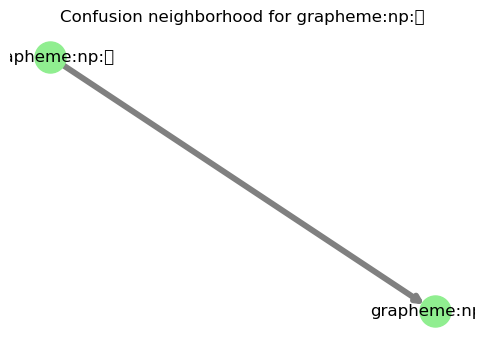


Top confusions for phoneme:np:/dʱʌ/:
  -> phoneme:np:/dʌ/ | Weight: 1.0 | Type: heuristic
  -> phoneme:np:/tʌ/ | Weight: 0.996 | Type: heuristic
  -> phoneme:np:/ɖʌ/ | Weight: 0.996 | Type: heuristic
  -> phoneme:np:/ɖʱʌ/ | Weight: 0.996 | Type: heuristic
  -> phoneme:np:/nʌ/ | Weight: 0.992 | Type: heuristic


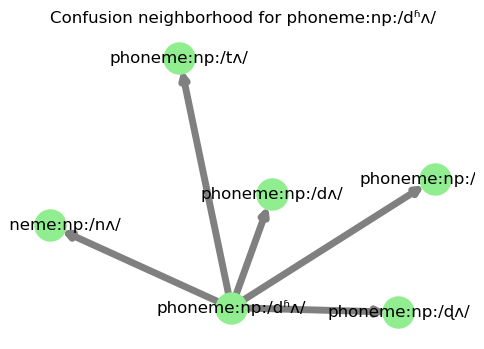

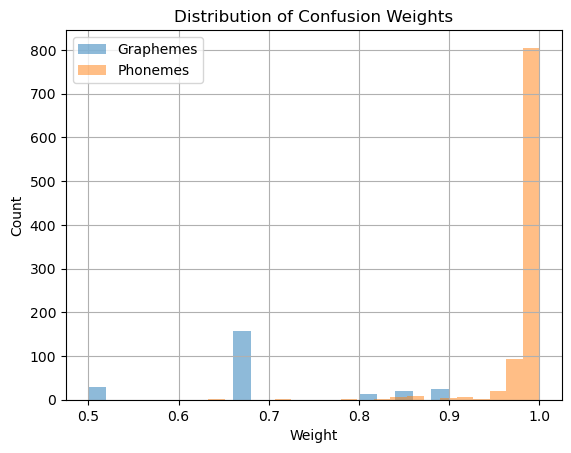

In [20]:
def show_top_confusions(G, node_id, top_n=10):
    if node_id not in G:
        print(f"Node {node_id} not found.")
        return
        
    print(f"\nTop confusions for {node_id}:")
    edges = [(v, d) for u, v, d in G.out_edges(node_id, data=True) if d.get('relation') in ['phonemeconfusablewith', 'graphemeconfusablewith']]
    edges = sorted(edges, key=lambda x: x[1].get('weight', 0), reverse=True)
    
    for v, d in edges[:top_n]:
        print(f"  -> {v} | Weight: {d.get('weight')} | Type: {d.get('source_type')}")

def plot_confusion_neighborhood(G, node_id):
    if node_id not in G: return
    
    edges = [(u, v, d) for u, v, d in G.out_edges(node_id, data=True) if d.get('relation') in ['phonemeconfusablewith', 'graphemeconfusablewith']]
    
    if not edges:
        return
        
    subgraph_nodes = set([node_id] + [v for u, v, d in edges])
    H = G.subgraph(subgraph_nodes)
    
    plt.figure(figsize=(6, 4))
    pos = nx.spring_layout(H, seed=42)
    
    nx.draw_networkx_nodes(H, pos, node_color='lightgreen', node_size=500)
    nx.draw_networkx_labels(H, pos)
    
    weights = [d.get('weight', 0.5) * 5 for u, v, d in edges]
    nx.draw_networkx_edges(H, pos, edgelist=[(u,v) for u,v,d in edges], width=weights, edge_color='gray')
    
    plt.title(f"Confusion neighborhood for {node_id}")
    plt.axis('off')
    plt.show()

# Examples
sample_grapheme = df_grapheme['source'].iloc[200] if not df_grapheme.empty else None
if sample_grapheme:
    show_top_confusions(G, sample_grapheme)
    plot_confusion_neighborhood(G, sample_grapheme)

sample_phoneme = df_phoneme['source'].iloc[202] if not df_phoneme.empty else None
if sample_phoneme:
    show_top_confusions(G, sample_phoneme)
    plot_confusion_neighborhood(G, sample_phoneme)

# Weight Distributions
if not df_grapheme.empty:
    df_grapheme['weight'].hist(alpha=0.5, label='Graphemes', bins=20)
if not df_phoneme.empty:
    df_phoneme['weight'].hist(alpha=0.5, label='Phonemes', bins=20)
plt.title('Distribution of Confusion Weights')
plt.xlabel('Weight')
plt.ylabel('Count')
plt.legend()
plt.show()


In [14]:
print(f"Exporting updated GraphML to {OUTPUT_GRAPH_PATH}...")
nx.write_graphml(G, OUTPUT_GRAPH_PATH)
print("Done!")


Exporting updated GraphML to artifacts/graph_phase2_scriptweights.graphml...
Done!
